In [2]:
import sys
import importlib
sys.path.insert(0, './hxetda/')
import hxetda
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support, classification_report
from sklearn.utils import class_weight
from keras.utils import to_categorical 
import tensorflow as tf
from tqdm.keras import TqdmCallback

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *

2026-08-10 15:03:37.834086: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-10 15:03:37.888782: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-10 15:03:39.959933: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
import tensorflow as tf

# Get the build information dictionary
build_info = tf.sysconfig.get_build_info()

# Print the CUDA version it was built for
print("CUDA Version TensorFlow was built with:", build_info.get('cuda_version', 'Not found'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CUDA Version TensorFlow was built with: 12.5.1
Num GPUs Available:  0


2026-08-10 15:03:41.860832: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

data = dp.extract_dataframe(master_df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
metadata = data[5]  # Sub-dataframe containing only the metadata
all_features = data[6]  # Only the flux values in a numpy array
fluxes0 = data[6]  # Only the flux values in a numpy array

labels = metadata.sn_type

In [5]:
vertices =  np.asarray(np.unique(labels),dtype=str)
vertices

array(['CaRT', 'II', 'IIb', 'IIn', 'Ia', 'Iap', 'Ib', 'Ic', 'SL', 'TDE'],
      dtype='<U4')

In [6]:
# Tell me a little about the data...
ulab, counts = np.unique(labels, return_counts=True)
for x,y in zip(ulab, counts):
    print(x,y, y/np.sum(counts))
print('Features',np.shape(all_features))

CaRT 52 0.0038681841850777355
II 1819 0.1353120583203154
IIb 542 0.04031838131369486
IIn 880 0.06546157851670015
Ia 8074 0.6006099828907238
Iap 263 0.0195640853976047
Ib 262 0.01948969724019936
Ic 193 0.014356914379230826
SL 1262 0.09387785464554042
TDE 96 0.007141263110912743
Features (13443, 139)


# Set up heirarchy

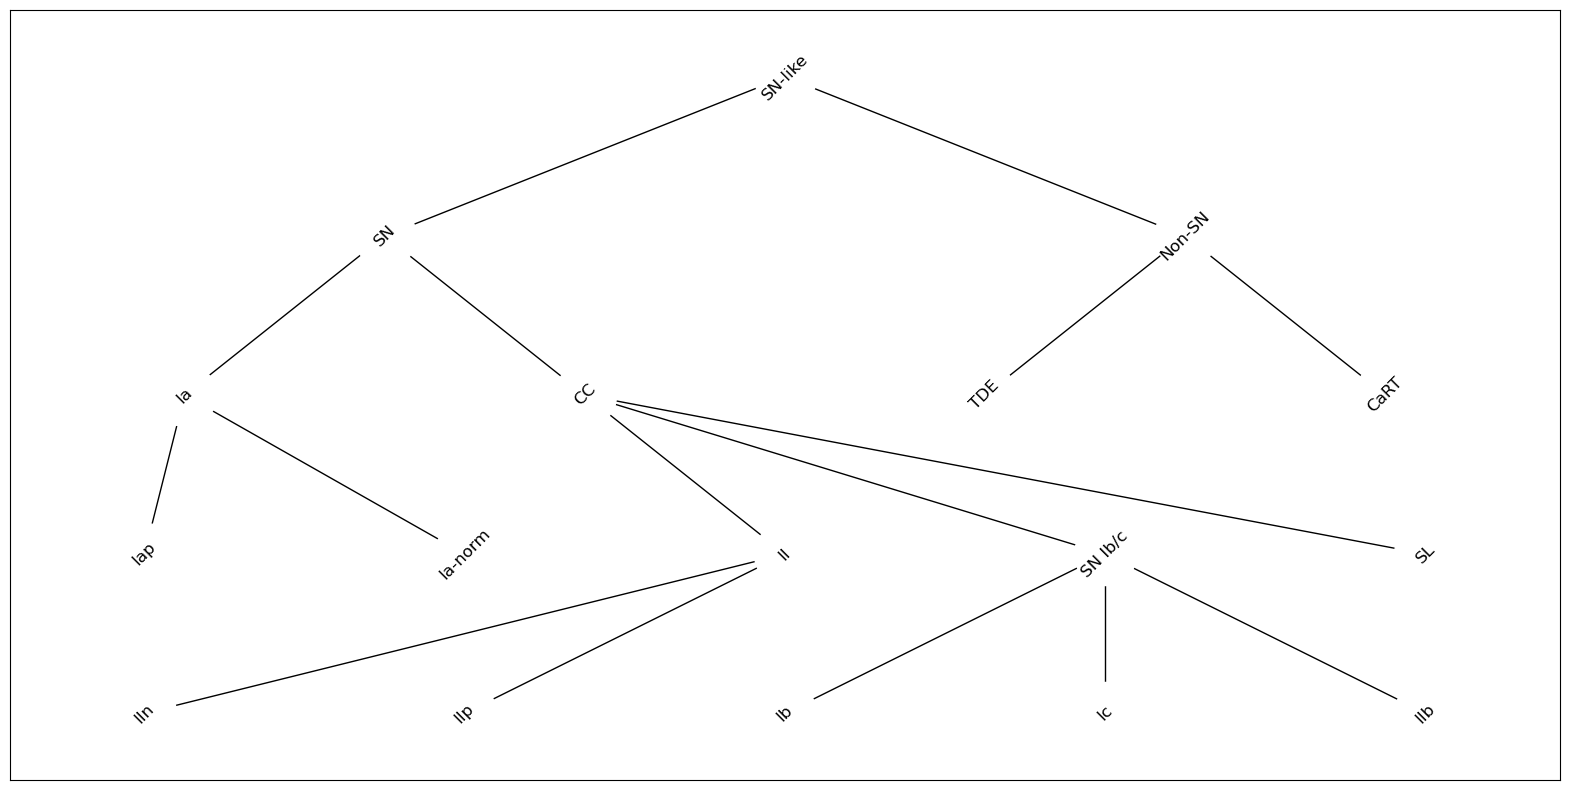

In [7]:
# Make a graph

# print(vertices)
G=nx.DiGraph()

# G.add_edge('Object','StellarTransient') #this does NOT include extragalactic transients
# G.add_edge('Object','SN-like')


# G.add_edge('StellarTransient','AGN')
# G.add_edge('AGN','QSO')

# G.add_edge('StellarTransient', 'CV')
# G.add_edge('StellarTransient', 'Nova')
# G.add_edge('StellarTransient', 'Varstar')

G.add_edge('SN-like', 'SN')
# G.add_edge('SN-like', 'ILOT')
# G.add_edge('ILOT', 'LBV')
# G.add_edge('ILOT', 'ILRT')
# G.add_edge('ILOT', 'LRN')
G.add_edge('SN-like', 'Non-SN') 
G.add_edge('Non-SN', 'TDE')
G.add_edge('Non-SN', 'CaRT')


# # changing to match current labels
# G.add_edge('SN', 'SN Ia')
# G.add_edge('SN Ia', 'SN Ia-91T')
# G.add_edge('SN Ia', 'SN Ia-91bg-like')
G.add_edge('SN', 'Ia')
G.add_edge('Ia', 'Iap')
G.add_edge('Ia', 'Ia-norm')


# G.add_edge('Ia', 'Iax') # in ABC-SN but not milligan

# G.add_edge('SN Ia', 'SN Ia-CSM')
# G.add_edge('SN Ia', 'SN Ia-SC')
# G.add_edge('SN Ia', 'SN Ia-pec')
# G.add_edge('SN Ia', 'SN Iax')


G.add_edge('SN', 'CC')

# G.add_edge('CC', 'SLSN-I')
G.add_edge('CC', 'II')

G.add_edge('CC', 'SN Ib/c')
G.add_edge('SN Ib/c', 'Ib')
# G.add_edge('SN Ib/c', 'SN Ib-pec')
# G.add_edge('SN Ib/c', 'SN Ibn')
G.add_edge('SN Ib/c', 'Ic')
# G.add_edge('SN Ib/c', 'SN Ic-BL') # broad?
# G.add_edge('SN Ib/c', 'SN Ic-broad') 
# G.add_edge('SN Ib/c', 'SN Ic-Ca-rich')
# G.add_edge('SN Ib/c', 'SN Ic-pec')
# G.add_edge('SN Ib/c', 'SN Ic-norm') 
G.add_edge('SN Ib/c', 'IIb')  # do under stripped envelope

# G.add_edge('CC', 'SLSN-II')
G.add_edge('CC', 'SL')
# G.add_edge('SN II', 'SN II-pec')


# G.add_edge('CC', 'IIn') # not sure why this is separate from SN II 
G.add_edge('II', 'IIn')
G.add_edge('II', 'IIp') # this is essentially normal "plateau"

importlib.reload(hxetda)
pos = hxetda.hierarchy_pos(G, 'SN-like')

fig = plt.figure(1, figsize=(20, 10))

nx.draw_networkx(G, pos=pos, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

# Load data + preprocessing

In [8]:
conversions = {'Ia':'Ia-norm',
                'II':'IIp' # i think this is fine
                }

In [9]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

def make_dataset(load=False):
    data = dp.extract_dataframe(master_df)
    
    metadata = data[5]  # Sub-dataframe containing only the metadata
    flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
    all_labels = metadata.sn_type.values
    vertices =  np.asarray(np.unique(all_labels),dtype=str)
    all_flux = data[6] 

    for key in conversions:
        gind = np.where(all_labels == key)
        if len(gind[0])==0:
            print(f"no labels: {key}")
        else:
            all_labels[gind] = conversions[key]
    
    vertices = np.asarray(np.unique(all_labels),dtype=str)
    print(np.unique(all_labels, return_counts=True))
    vertices = np.append(vertices, ['Non-SN', 'SN', 'CC', "SN Ib/c", "Ia", "II"])
    vertices = np.insert(vertices, 0, 'SN-like')

    return(all_labels, vertices)

labels, vertices = make_dataset()
scaler.fit(all_features)
all_features = scaler.transform(all_features)

(array(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL',
       'TDE'], dtype=object), array([  52,  542,  880, 1819, 8074,  263,  262,  193, 1262,   96]))


In [10]:
leaves = np.asarray(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL','TDE'], dtype=str)

In [11]:
# Some pre-processing for the graph
importlib.reload(hxetda)
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'SN-like')

In [12]:
mask_list

[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]),
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1]),
 tensor([0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])]

In [13]:
# Some pre-processing for the class weights

class_weight_dict = hxetda.calc_class_weights(labels, vertices, paths)
print(class_weight_dict.keys())

dict_keys(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL', 'TDE'])


In [14]:
class_weight_dict

{'CaRT': array([25.85192308]),
 'IIb': array([2.4802583]),
 'IIn': array([1.52761364]),
 'IIp': array([0.73903244]),
 'Ia-norm': array([0.1664974]),
 'Iap': array([5.11140684]),
 'Ib': array([5.13091603]),
 'Ic': array([6.96528497]),
 'SL': array([1.06521395]),
 'TDE': array([14.003125])}

In [13]:
# Set up for train test split...
# labels_new = [y_dict[x] for x in labels] # multiple hot encoding of sorts
# weights = [class_weight_dict[x] for x in labels]
# X_train, X_test, y_train, y_test, labels_train, labels_test, weights_train, weights_test = train_test_split(all_features, labels_new, labels, weights,test_size=0.33)
# X_train = torch.tensor(X_train, dtype=torch.float32)
# X_test = torch.tensor(X_test, dtype=torch.float32)
# y_train = torch.tensor(y_train, dtype=torch.float32)
# y_test = torch.tensor(y_test, dtype=torch.float32)

# weights_train = torch.tensor(weights_train, dtype=torch.float32)
# weights_test = torch.tensor(weights_test, dtype=torch.float32)

# print(np.shape(X_train))

# Set up training and model

In [14]:
# Set up for train test split...
index = master_df.index.values
y_mhe = np.array([y_dict[x] for x in labels]) # "multi hot encoding"
weights = np.array([class_weight_dict[x] for x in labels])
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

# Getting index of the train test split
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = labels)

# splitting all the inputs
X_train = X[train_index]
X_test = X[test_index]

y_train = y_mhe[train_index]
y_test = y_mhe[test_index]

weights_train = weights[train_index]
weights_test = weights[test_index]

In [15]:
y_mhe[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 0.])

In [16]:
y_mhe

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9410, 1, 139), (4033, 1, 139), (9410, 17), (4033, 17))

## Loss function

In [19]:
## Generated by AI

# class HierarchicalLoss:
#     def __init__(self, mask_list, pathlengths, alpha=0.5):
#         """
#         Args:
#             mask_list: List of mask tensors for hierarchical softmax
#             pathlengths: Array of path lengths for each sample
#             alpha: Scaling factor
#         """
#         self.mask_list = [tf.constant(mask, dtype=tf.float32) for mask in mask_list]
#         self.pathlengths = tf.constant(pathlengths, dtype=tf.float32)
#         self.alpha = alpha
        
#     def masked_softmax(self, vec, mask, dim=1, epsilon=1e-10):
#         """Masked softmax implementation"""
#         mask_float = tf.cast(mask, tf.float32)
#         masked_vec = vec * mask_float
#         exps = tf.exp(masked_vec)
#         masked_exps = exps * mask_float
#         masked_sums = tf.reduce_sum(masked_exps, axis=dim, keepdims=True) + epsilon
#         final_vec = masked_exps / masked_sums + ((1.0 - mask_float) * vec)
#         return final_vec
    
#     def __call__(self, y_true, y_pred):
#         """
#         Loss function called by Keras - DOES NOT take sample_weight as argument
#         Sample weights are handled separately by Keras
#         """
#         # Make a copy and set first column to 1.0
#         output = tf.identity(y_pred)
#         output = tf.concat([tf.ones_like(output[:, :1]), output[:, 1:]], axis=1)

        
#         # Apply hierarchical softmax
#         for mask in self.mask_list:
#             output = self.masked_softmax(output, mask)

        
#         # Apply log
#         output = tf.math.log(output + 1e-10)

        
#         # Apply path length scaling
#         pathlengths_tensor = tf.reshape(self.pathlengths, [1, -1])
#         scaling_factor = tf.exp(-self.alpha * (pathlengths_tensor - 1.0))
#         output = output * scaling_factor

        
#         # Compute loss per sample
#         loss_per_sample = tf.reduce_sum(output * y_true, axis=1)
        
#         final_loss = tf.reduce_mean(loss_per_sample)

        
#         # Return negative loss (to minimize)
#         return -final_loss

            
#         # Return mean loss (Keras will apply sample weights if provided)
#         return -tf.reduce_mean(loss_per_sample)

# # Use the class version
# loss_fn = HierarchicalLoss(mask_list, pathlengths, alpha=0.5)

#### New Version 



# Use the class version
# loss_fn = HierarchicalLoss(mask_list, pathlengths, alpha=0.5)

In [ ]:
pathlengths

## Add Callbacks

In [ ]:
# early stopping 
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        # min_delta=1e-2, # stated during meeting (note higher than willows)
        min_delta=1e-3, 
        patience= 25, # stated in meeting + same as willows
        verbose=2,
        mode="min",
        restore_best_weights=True 
        )

# model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint{epoch}.keras" # this one creates many files
model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint_weighted_loss.keras"
model_checkpoints = keras.callbacks.ModelCheckpoint(
    model_filepath,
    monitor="val_loss",
    verbose=0,
    save_freq = 10,
    mode="min",
    save_best_only=True
    )

epoch_bound = 100
batch_size = 64 # used below
step_bound = len(train_index) * epoch_bound // batch_size

learning_rate_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[step_bound],  # Epoch when the change happens
    values=[1e-5, 2e-6]  # Learning rates: [before boundary, after boundary]
    )

## Add New Layer to Model

In [ ]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)

In [ ]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
new_model = keras.Model(
    inputs=abcsn.input, 
    outputs=abcsn.layers[-2].output)

from tensorflow.keras import layers

new_output = layers.Dense(17, activation="softmax", name="heirarchical_dense")(new_model.output)
heir_abcsn = keras.Model(inputs=new_model.input, outputs=new_output)

In [ ]:
heir_abcsn.summary()

In [ ]:
len(heir_abcsn.trainable_variables)

## Compile Model

In [ ]:
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
optimizer = keras.optimizers.Nadam(learning_rate=learning_rate_schedule)

# Compile your model
heir_abcsn.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=[acc, f1]
)



In [22]:
type(X_train)

numpy.ndarray

# Train

In [46]:
# weights are implemented incorrectly
history = heir_abcsn.fit(X_train, y_train, 
                    sample_weight=weights_train,
                    validation_data= (X_test, y_test, weights_test), 
                    epochs = 100,    # choosen arbitrarily 
                    batch_size = 64, # same as willow used
                    verbose= 0,
                    callbacks=[model_checkpoints, early_stop, TqdmCallback(verbose=0)],
                   )

  0%|          | 0/100 [00:00<?, ?epoch/s]2026-08-05 12:17:34.080190: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


TypeError: Cannot serialize object tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]) of type <class 'torch.Tensor'>. To be serializable, a class must implement the `get_config()` method.

In [ ]:
log = history.history
abcsn_training.plot_loss(log, scale=4, cb_es=None, patience_es=None)
plt.axvline(epoch_bound, label= "learning rate change", color = 'k')
# plt.axvline(485, label= "best epoch", color = 'g')
plt.legend()
# plt.ylim(4,5)

In [ ]:
# model_name = "heirarchical_model"
# heir_abcsn.save(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/{model_name}.keras")
# (pd.DataFrame(log)).to_csv(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/{model_name}.csv")

In [ ]:
df_test = master_df.iloc[test_index].copy()

In [ ]:
heir_abcsn = keras.models.load_model(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/heirarchical_model.keras", compile=False)

In [ ]:

# predict type
P = heir_abcsn.predict(X_test, verbose=0)
# P_argmax = np.argmax(P, axis=1)

# df_test["Pred_ABC_ID"] = P_argmax

# # get type as milligan ID
# ABC_to_Mill = get_ABC_to_Mill_dict()
# P_Mill = np.array([ABC_to_Mill[i] for i in P_argmax])
# df_test["Pred_Mill_ID"] = P_Mill

In [ ]:
vertices

In [ ]:
Y_ABC_IDs = df_test.ABC_type.values
leaves = np.asarray(['Ia', 'SN Ib/c', 'II', 'SL', 'Non-SN'], dtype=str)

In [ ]:
y_pred.shape

In [ ]:
y_pred = torch.from_numpy(P)
probs_list = np.zeros((len(y_pred), len(leaves)))
for i,leaf in enumerate(leaves):
    probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

In [ ]:
probs_list

In [ ]:
P_argmax = np.argmax(probs_list, axis=1)

In [ ]:
np.unique(P_argmax)

In [ ]:
specific_class = 'Ia'
single_class_prob = hxetda.get_prob(y_pred,specific_class, paths, vertices, mask_list).detach().numpy()
plt.hist(single_class_prob)
plt.yscale('log')

In [ ]:
df_test["Mill_type"].unique()

In [ ]:
df_test["sn_type"].unique()

In [ ]:
df_test[df_test["sn_type"] == "SL"]

In [ ]:
np.unique(P_argmax)

In [ ]:

cr = (classification_report(
    df_test["Mill_type"].values,
    P_argmax,
    # target_names=['Ia', 'SN Ib/c', 'II', 'SL', 'CC'],
    # labels= [0,1,2,3,4]
    ))

# print(cr)

In [ ]:
# #Play around with different classes
# specific_class = 'SN Ib'
# single_class_prob = hxetda.get_prob(y_pred,specific_class, paths, vertices, mask_list).detach().numpy()
# plt.hist(single_class_prob)
# plt.yscale('log')

# gind = np.where(single_class_prob>0.1)
# print(labels_test[gind])
# gind2 = np.where(labels_test == specific_class)
# plt.hist(single_class_prob[gind2])
# print(len(gind2[0]))


# 5-way task

In [ ]:
# # 5-way task...
# # Get my leaves...
# importlib.reload(hxetda)

# leaves = np.asarray(['SN Ia','SN Ib/c', 'SN II', 'SLSN-I', 'SN IIn'], dtype=str)
# probs_list = np.zeros((len(y_pred), len(leaves)))
# for i,leaf in enumerate(leaves):
#     probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

# my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

# fiveleaf_labels_test = np.copy(labels_test)

# for i,s in enumerate(fiveleaf_labels_test):
#     is_Ibc = hxetda.is_parent(s, 'SN Ib/c', vertices, paths)
#     if is_Ibc:
#         fiveleaf_labels_test[i] = 'SN Ib/c'

# gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
# cm = confusion_matrix(fiveleaf_labels_test[gind], my_predicted_types[gind], labels=leaves)
# disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)
# print(len(gind))
# print(leaves)
# print(labels_test[gind][9], probs_list[gind][9])

# print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='macro'))
# print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='micro'))

In [ ]:
# # Now for the same training/test set...train a baseline
# # Train!

# gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
# baseline_Xtest = X_test[gind]
# baseline_ytest = y_test[gind]
# baseline_labels_test = fiveleaf_labels_test[gind]

# print(len(gind))

# gind = np.where(np.in1d(labels_train,leaves))[0]
# baseline_Xtrain = X_train[gind]
# baseline_ytrain = y_train[gind]
# baseline_labels_train = labels_train[gind]

# # Now only keep relevant columns...

# new_baseline_ytest = np.zeros((len(baseline_ytest), len(leaves)))
# new_baseline_ytrain = np.zeros((len(baseline_ytrain), len(leaves)))

# for i,leaf in enumerate(leaves):
#     j = np.where(leaf == vertices)[0][0]
#     new_baseline_ytrain[:,i] = baseline_ytrain[:,j]
#     new_baseline_ytest[:,i] = baseline_ytest[:,j]

# baseline_ytrain = torch.tensor(new_baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(leaves))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.01)
# model_baseline.train()
# epoch = 2000
# n_batches = 1024


# #class_weights=class_weight.compute_class_weight('balanced',classes=np.unique(labels_test),y=my_predicted_types)

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# 	#scheduler.step()
# plt.show()

In [ ]:
leaves = np.asarray(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL','TDE'], dtype=str)


In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = leaves[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(baseline_labels_test, predicted_baseline_types, labels=leaves)
# disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(baseline_labels_test, predicted_baseline_types,average='micro'))

# Sibling task

In [ ]:
# importlib.reload(hxetda)

# siblings = np.asarray(['StellarTransient', 'Supernova-like'])
# probs_list = np.zeros((len(y_pred), len(siblings)))
# for i,sib in enumerate(siblings):
#     probs_list[:,i] = hxetda.get_prob(y_pred,sib, paths, vertices, mask_list).detach().numpy()

# my_predicted_types = siblings[np.argmax(probs_list,axis=1)]

# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#     else:
#         sibling_labels_test[i] = 'Supernova-like'


# cm = confusion_matrix(sibling_labels_test, my_predicted_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, my_predicted_types,average='micro'))

In [ ]:
# And now baseline...
# # Now for the same training/test set...train a baseline
# # Train!

# siblings = np.asarray(['StellarTransient', 'Supernova-like'])

# baseline_ytest = np.zeros((len(y_test), len(siblings)))
# sibling_labels_test = np.copy(labels_test)
# for i,s in enumerate(sibling_labels_test):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_test[i] = 'StellarTransient'
#         baseline_ytest[i,0] = 1

#     else:
#         sibling_labels_test[i] = 'Supernova-like'
#         baseline_ytest[i,1] = 1



# baseline_ytrain = np.zeros((len(y_train), len(siblings)))
# sibling_labels_train = np.copy(labels_train)
# for i,s in enumerate(sibling_labels_train):
#     is_StellarTransient = hxetda.is_parent(s, 'StellarTransient', vertices, paths)

#     if is_StellarTransient:
#         sibling_labels_train[i] = 'StellarTransient'
#         baseline_ytrain[i,0] = 1

#     else:
#         sibling_labels_train[i] = 'Supernova-like'
#         baseline_ytrain[i,1] = 1


# baseline_ytrain = torch.tensor(baseline_ytrain)
# baseline_ytest = torch.tensor(baseline_ytest)

# model_baseline = hxetda.Feedforward(np.shape(X_test[0])[0],15, len(siblings))
# optimizer = torch.optim.AdamW(model_baseline.parameters(), lr = 0.05)
# model_baseline.train()
# epoch = 1000
# n_batches = 1024

# baseline_Xtrain = torch.tensor(np.copy(X_train))
# baseline_Xtest = torch.tensor(np.copy(X_test))

# myloss = torch.nn.CrossEntropyLoss()

# for epoch in range(epoch):
# 	for i in range(int(len(baseline_Xtrain)/n_batches)+1):
# 		# Local batches and labels
# 		local_X, local_y = baseline_Xtrain[i*n_batches:(i+1)*n_batches,], baseline_ytrain[i*n_batches:(i+1)*n_batches,]
# 		optimizer.zero_grad()
# 		# Forward pass
# 		y_pred_baseline = model_baseline(local_X)
# 		# Compute Loss
# 		loss = myloss(y_pred_baseline,local_y)
# 		# Backward pass
# 		loss.backward()
# 		optimizer.step()
# 		plt.plot(epoch,loss.detach().numpy(),'ko')
# plt.show()

In [ ]:
# model_baseline.eval()
# y_pred_baseline = model_baseline(baseline_Xtest).detach().numpy()
# predicted_baseline_types = siblings[np.argmax(y_pred_baseline,axis=1)]
# cm = confusion_matrix(sibling_labels_test, predicted_baseline_types, labels=siblings)
# disp = ConfusionMatrixDisplay(cm, display_labels=siblings)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)

# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='macro'))
# print(precision_recall_fscore_support(sibling_labels_test, predicted_baseline_types,average='micro'))